<h1 style="text-align:center; color:green; font-size:48px;">
DHNx TUTORIAL
</h1>

#### Install libraries (if you did not do it before on the terminal)

In [7]:
#!pip install numpy==2.0.2 pandas==2.3.1
#!pip install matplotlib
#!pip install git+https://github.com/oemof/dhnx.git@dev
#!pip install osmnx==1.9.4 oemof.solph==0.5.6

# Import libraries

In [8]:
import matplotlib.pyplot as plt
import dhnx
import pandas as pd
import oemof.solph
from pyomo.environ import SolverFactory

# Example 1 

## 1.1 Create network and plot

In [9]:
# Initialize thermal network
network = dhnx.network.ThermalNetwork()

# Load town parameter
network = network.from_csv_folder(r"Input_data/twn_data")

# Load investment parameter
invest_opt = dhnx.input_output.load_invest_options(r"Input_data/invest_data")

INFO:root:Attribute 'heat_flow' is not part of the component attributes.


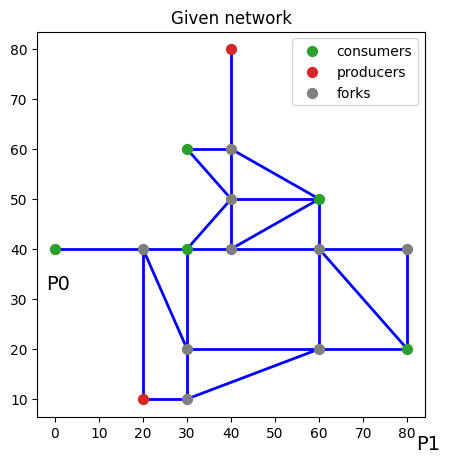

In [10]:
# plot initial/given network
static_map = dhnx.plotting.StaticMap(network) # That's how DHNx plots the network
static_map.draw(background_map=False) # This line to show the network on a blank area.
plt.title('Given network') 

#Scatter plots to differentiate the consumers, producers and forks. 
plt.scatter(network.components.consumers['lon'], network.components.consumers['lat'],
            color='tab:green', label='consumers', zorder=2.5, s=50) 
plt.scatter(network.components.producers['lon'], network.components.producers['lat'],
            color='tab:red', label='producers', zorder=2.5, s=50)
plt.scatter(network.components.forks['lon'], network.components.forks['lat'],
            color='tab:grey', label='forks', zorder=2.5, s=50)
plt.text(-2, 32, 'P0', fontsize=14)
plt.text(82, 0, 'P1', fontsize=14)
plt.legend()
plt.show()

## 1.2 Investment optimization of the network

In [11]:
# Optimize the investment data
network.optimize_investment(invest_options=invest_opt,  solver='glpk')


INFO:dhnx.optimization.optimization_models:Initialize the energy system
INFO:dhnx.optimization.optimization_models:Create oemof objects
INFO:dhnx.optimization.optimization_models:Producers, Consumers Nodes appended.
c:\Users\rodri\anaconda3\envs\env_P2\lib\site-packages\oemof\solph\flows\_flow.py:163: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)
c:\Users\rodri\anaconda3\envs\env_P2\lib\site-packages\oemof\network\network\nodes.py:250: FutureWarning: Usage of oemof.network.Component is deprecated. Use oemof.network.Node instead.
  warnings.warn(
INFO:dhnx.optimization.optimization_models:DHS Nodes appended.
INFO:dhnx.optimization.optimization_models:Energysystem has been created
INFO:dhnx.optimization.optimization_models:Build the operational model
INFO:dhnx.optimization.optimization_models:Solve the optimization problem


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\rodri\AppData\Local\Temp\tmpco7r49fy.glpk.raw --wglp C:\Users\rodri\AppData\Local\Temp\tmplmb1x8dc.glpk.glp
 --cpxlp C:\Users\rodri\AppData\Local\Temp\tmppzidn6rh.pyomo.lp
Reading problem data from 'C:\Users\rodri\AppData\Local\Temp\tmppzidn6rh.pyomo.lp'...
C:\Users\rodri\AppData\Local\Temp\tmppzidn6rh.pyomo.lp:4122: warning: lower bound of variable 'x72' redefined
C:\Users\rodri\AppData\Local\Temp\tmppzidn6rh.pyomo.lp:4122: warning: upper bound of variable 'x72' redefined
646 rows, 562 columns, 1472 non-zeros
70 integer variables, all of which are binary
4192 lines were read
Writing problem data to 'C:\Users\rodri\AppData\Local\Temp\tmplmb1x8dc.glpk.glp'...
3600 lines were written
GLPK Integer Optimizer 5.0
646 rows, 562 columns, 1472 non-zeros
70 integer variables, all of which are binary
Preprocessing...
574 rows, 560 columns, 1394 non-zeros
70 integer variables, all of which are binary
Scal

INFO:root:Optimization successful...


## 1.3 Results postprocessing and Plotting 


      from_node      to_node hp_type     capacity  direction          costs  \
id                                                                            
0       forks-0  consumers-0    DN32    74.630344          1  414793.891429   
1   producers-0      forks-0    DN80   226.691798          1  669232.122314   
2   producers-0      forks-2    None     0.000000          0       0.000000   
3       forks-2      forks-1    None     0.000000          0       0.000000   
4       forks-1      forks-0    None     0.000000          0       0.000000   
5       forks-0  consumers-1    DN32   150.902068          1  207434.703993   
6       forks-1  consumers-1    None     0.000000          0       0.000000   
7       forks-1      forks-7    None     0.000000          0       0.000000   
8       forks-2      forks-7    None     0.000000          0       0.000000   
9       forks-6      forks-7    None     0.000000          0       0.000000   
10      forks-7  consumers-4    None     0.000000   

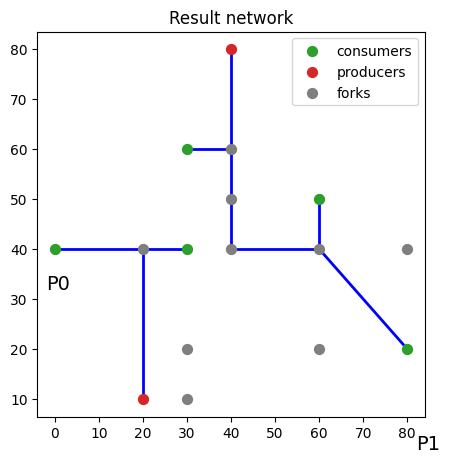

In [12]:
# ####### Postprocessing and Plotting ###########
results_edges = network.results.optimization['components']['pipes']
print(results_edges[['from_node', 'to_node', 'hp_type', 'capacity',
                     'direction', 'costs', 'losses']])

import os

# Create the folder if it does not exist
os.makedirs("Outputs", exist_ok=True)

# Now save the results
results_edges.to_csv("Outputs/Ex1.results_edges.csv", index=True)


print('Objective value: ', network.results.optimization['oemof_meta']['objective'])

# assign new ThermalNetwork with invested pipes
twn_results = network
twn_results.components['pipes'] = results_edges[results_edges['capacity'] > 0.001]

# plot invested edges
static_map_2 = dhnx.plotting.StaticMap(twn_results)
static_map_2.draw(background_map=False)
plt.title('Result network')
plt.scatter(network.components.consumers['lon'], network.components.consumers['lat'],
            color='tab:green', label='consumers', zorder=2.5, s=50)
plt.scatter(network.components.producers['lon'], network.components.producers['lat'],
            color='tab:red', label='producers', zorder=2.5, s=50)
plt.scatter(network.components.forks['lon'], network.components.forks['lat'],
            color='tab:grey', label='forks', zorder=2.5, s=50)
plt.text(-2, 32, 'P0', fontsize=14)
plt.text(82, 0, 'P1', fontsize=14)
plt.legend()
plt.show()